In [2]:
import pandas as pd

import os

DATA_DIR = "../data"

single_path = os.path.join(DATA_DIR, "single_true_multi_choice_qa.jsonl")
multi_path = os.path.join(DATA_DIR, "multi_true_multi_choice_qa.jsonl")

single = pd.read_json(single_path, lines=True)
multi = pd.read_json(multi_path, lines=True)

FileNotFoundError: File ../data/single_true_multi_choice_qa.jsonl does not exist

In [11]:
import sys
print(sys.executable)

/opt/anaconda3/envs/tf311/bin/python


In [12]:
import sys
!{sys.executable} -m pip install openpyxl

In [13]:
import openpyxl
print(openpyxl.__version__)

3.1.5


In [9]:
import pandas as pd

with pd.ExcelWriter("sensor_failure_dataset.xlsx") as writer:
    single.to_excel(writer, sheet_name="single_answer", index=False)
    multi.to_excel(writer, sheet_name="multi_answer", index=False)

# I like to look at things in Excel

In [14]:
# basic EDA

# Distribution of Assets
print(single['asset_name'].value_counts())

# Distribution of Task Logic
print(single['relevancy'].value_counts())


asset_name
power transformer                           544
aero gas turbine                            336
reciprocating internal combustion engine    336
industrial gas turbine                      240
electric motor                              234
electric generator                          234
compressor                                  220
fan                                         200
steam turbine                               171
pump                                        152
Name: count, dtype: int64
relevancy
irrelevant_sensors_for_failure_mode    872
irrelevant_failure_modes_for_sensor    872
relevant_sensors_for_failure_mode      470
relevant_failure_modes_for_sensor      453
Name: count, dtype: int64


In [6]:
# Check the balance of logic per asset
cross_tab = pd.crosstab(single['asset_name'], single['relevancy'])
print(cross_tab)

relevancy                                 irrelevant_failure_modes_for_sensor  \
asset_name                                                                      
aero gas turbine                                                          105   
compressor                                                                 63   
electric generator                                                         83   
electric motor                                                             79   
fan                                                                        62   
industrial gas turbine                                                     78   
power transformer                                                         185   
pump                                                                       44   
reciprocating internal combustion engine                                  124   
steam turbine                                                              49   

relevancy                  

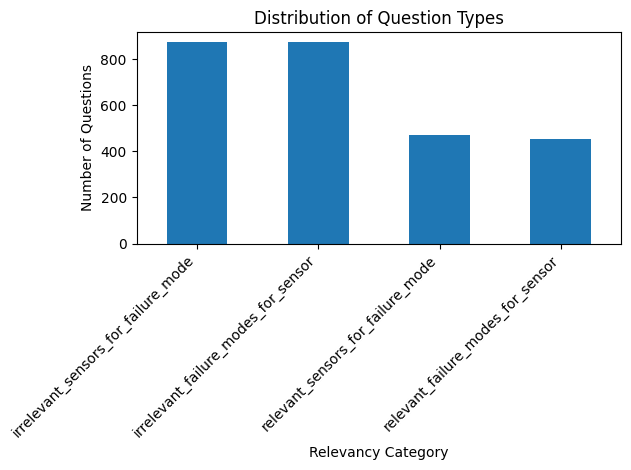

In [17]:
single['relevancy'].value_counts().plot(kind='bar')

plt.title("Distribution of Question Types")
plt.ylabel("Number of Questions")
plt.xlabel("Relevancy Category")

plt.xticks(rotation=45, ha='right')  # key fix
plt.tight_layout()

plt.show()

In [18]:
single['relevancy'].value_counts()

relevancy
irrelevant_sensors_for_failure_mode    872
irrelevant_failure_modes_for_sensor    872
relevant_sensors_for_failure_mode      470
relevant_failure_modes_for_sensor      453
Name: count, dtype: int64

In [7]:
# Find which letter is correct for each row
def get_label(row):
    return row['option_ids'][row['correct'].index(True)]

single['correct_label'] = single.apply(get_label, axis=1)
print(single['correct_label'].value_counts())

correct_label
A    753
B    701
C    480
D    416
E    317
Name: count, dtype: int64


In [19]:
multi['num_correct'] = multi['correct'].apply(sum)
print(multi['num_correct'].describe())

count    5629.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
Name: num_correct, dtype: float64


In [9]:
from collections import Counter
import re

# Simple keyword extraction from the question text
all_words = " ".join(single['question']).lower()
keywords = re.findall(r'\b\w{5,}\b', all_words) # words longer than 5 chars
print(Counter(keywords).most_common(10))

[('sensor', 2434), ('which', 2396), ('failure', 2124), ('abnormal', 1325), ('choices', 1286), ('event', 1244), ('reading', 872), ('turbine', 807), ('power', 717), ('relevant', 710)]


In [10]:
# Extract failure modes from questions to see if they are unique or repetitive
df_motor = single[single['asset_name'] == 'electric motor']
print(df_motor['question'].value_counts().head(10))

question
Which sensor out of the choices does not indicate the presence of eccentric rotor fault in asset electric motor?                                                                    4
Which sensor out of the choices is not effective in indicating the presence of misalignment in electric motor?                                                                      4
In electric motor, when rotor windings fault occurs, which sensor from the choices is most critical in detecting the occurrence of the failure event?                               3
When a electric motor has bearing damage, which sensor out of the choices should be the sensor to be monitored for this failure if I want to build an anomaly detection model?      3
For electric motor, if brush(es) fault occurs, which sensor among the choices is least likely to be relevant in identifying this failure?                                           3
In electric motor, which sensor among the choices is least useful for detecting u

In [11]:
# Look at the options for the most common question
top_q = df_motor['question'].value_counts().index[0]
sample_options = df_motor[df_motor['question'] == top_q]['options'].values
for i, opt in enumerate(sample_options):
    print(f"Set {i+1}: {opt}")

Set 1: ['resistance', 'vibration', 'axial flux', 'current']
Set 2: ['current', 'partial discharge', 'vibration', 'axial flux']
Set 3: ['vibration', 'axial flux', 'torque', 'current']
Set 4: ['current', 'cooling gas', 'vibration', 'axial flux']


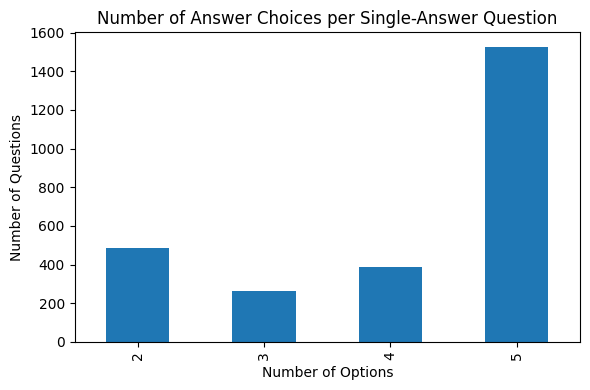

In [49]:
single['num_options'] = single['options'].apply(len)

plt.figure(figsize=(6,4))
single['num_options'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Answer Choices per Single-Answer Question")
plt.xlabel("Number of Options")
plt.ylabel("Number of Questions")
plt.tight_layout()
plt.show()

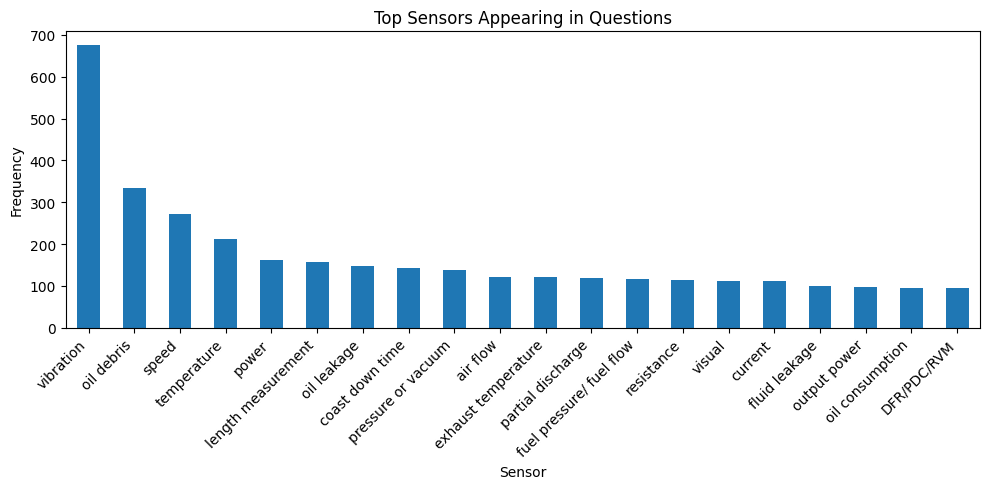

In [34]:
# Filter to questions where options are sensors
sensor_df = single[
    single['relevancy'].isin([
        'relevant_sensors_for_failure_mode',
        'irrelevant_sensors_for_failure_mode'
    ])
]

from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# Flatten sensor options
all_sensors = [sensor for sublist in sensor_df['options'] for sensor in sublist]

sensor_counts = Counter(all_sensors)

# Top 20 sensors
sensor_series = pd.Series(sensor_counts).sort_values(ascending=False).head(20)
sensor_series = sensor_series.rename(index={
    'dielecric frequency response (dfr)/ polarization and de-polarization current (pdc)/ recovery voltage method (rvm)': "DFR/PDC/RVM"
})

plt.figure(figsize=(10,5))
sensor_series.plot(kind='bar')

plt.title("Top Sensors Appearing in Questions")
plt.xlabel("Sensor")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

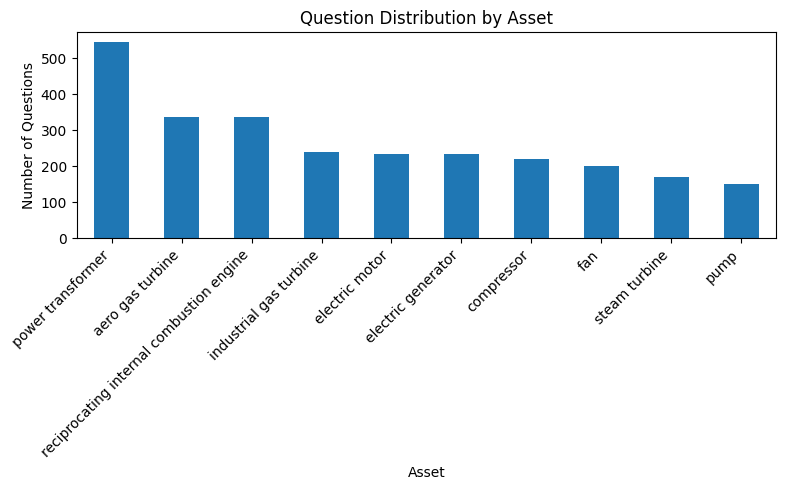

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

single['asset_name'].value_counts().plot(kind='bar')

plt.title("Question Distribution by Asset")
plt.xlabel("Asset")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

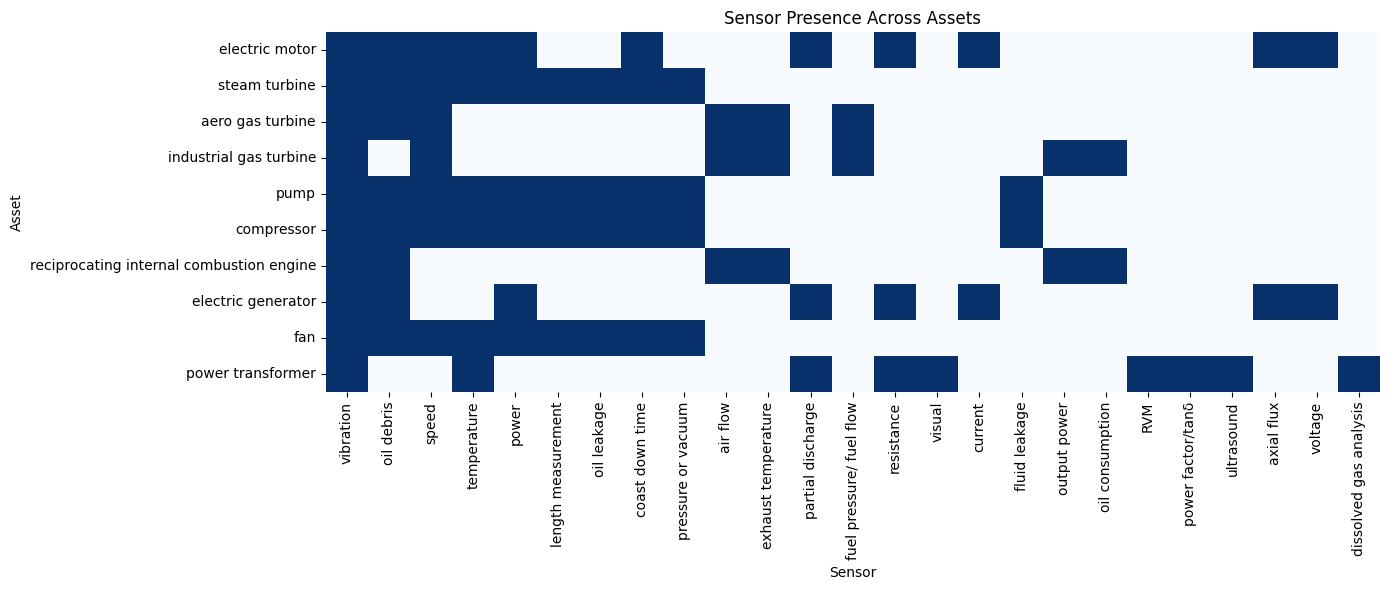

In [37]:
import seaborn as sns
import pandas as pd

rows = []

for asset in sensor_df['asset_name'].unique():
    
    df_asset = sensor_df[sensor_df['asset_name'] == asset]
    
    sensors = set(sensor for sublist in df_asset['options'] for sensor in sublist)
    
    row = {"asset": asset}
    
    for sensor in sensors:
        row[sensor] = 1
        
    rows.append(row)

heatmap_df = pd.DataFrame(rows).set_index("asset").fillna(0)

# Limit to top sensors so the heatmap is readable
top_sensors = pd.Series(all_sensors).value_counts().head(25).index
heatmap_df = heatmap_df[top_sensors]
heatmap_df = heatmap_df.rename(columns={
    'dielecric frequency response (dfr)/ polarization and de-polarization current (pdc)/ recovery voltage method (rvm)': "RVM"
})

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_df,
    cmap="Blues",
    cbar=False
)

plt.title("Sensor Presence Across Assets")
plt.xlabel("Sensor")
plt.ylabel("Asset")

plt.tight_layout()
plt.show()

In [13]:
# Check for "Transformer" sensors in "Motor" options
transformer_keywords = ['gas', 'oil', 'dga', 'bushing', 'tap changer']
motor_options_str = " ".join(all_motor_options).lower()

leaked_terms = [word for word in transformer_keywords if word in motor_options_str]
print(f"Potential Transformer terms found in Motor options: {leaked_terms}")

Potential Transformer terms found in Motor options: ['gas', 'oil']


In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, f1_score

def evaluate_failuresensor_iq(df_eval, df_preds):
    """
    Calculates weighted IQ scores based on the 3 dimensions identified in EDA.
    """
    # Merge predictions with ground truth on 'id' and 'subject'
    results = pd.merge(df_eval, df_preds[['id', 'subject', 'prediction']], on=['id', 'subject'])
    
    # 1. Physics Knowledge (Accuracy on Positive Relevancy)
    pos_mask = results['relevancy'].str.contains('relevant')
    physics_score = (results[pos_mask]['prediction'] == results[pos_mask]['correct_label']).mean()
    
    # 2. Negative Logic (Accuracy on Irrelevant Relevancy)
    neg_mask = results['relevancy'].str.contains('irrelevant')
    logic_score = (results[neg_mask]['prediction'] == results[neg_mask]['correct_label']).mean()
    
    # 3. Asset Isolation (Accuracy on "Leaked" Term questions)
    # Questions containing 'oil' or 'gas' for Motor assets
    leak_mask = (results['asset_name'] == 'electric motor') & \
                (results['options'].apply(lambda x: any(term in str(x).lower() for term in ['oil', 'gas'])))
    isolation_score = (results[leak_mask]['prediction'] == results[leak_mask]['correct_label']).mean()
    
    # 4. Positional Bias Check (Is the model just picking A/B?)
    pred_dist = results['prediction'].value_counts(normalize=True)
    
    return {
        "Physics_IQ": physics_score,
        "Logic_IQ": logic_score,
        "Isolation_IQ": isolation_score,
        "Top_Predicted_Label": pred_dist.idxmax(),
        "Label_Bias_Severity": pred_dist.max() - (1/len(pred_dist)) # Higher = more biased
    }


import random

predictions = single[['id', 'subject']].copy()
predictions['prediction'] = [random.choice(['A', 'B', 'C', 'D', 'E']) for _ in range(len(single))]

scores = evaluate_failuresensor_iq(single, predictions)
print(scores)
# Result should be roughly 0.20 (20%)


{'Physics_IQ': 0.20547431571053618, 'Logic_IQ': 0.20527522935779816, 'Isolation_IQ': 0.17307692307692307, 'Top_Predicted_Label': 'A', 'Label_Bias_Severity': 0.004724409448818884}


In [15]:
def print_iq_report(scores, model_name="Random Baseline"):
    print(f"--- FailuresensorIQ Report: {model_name} ---")
    print(f"{'Dimension':<20} | {'Score':<10} | {'Status'}")
    print("-" * 45)
    
    for metric, value in scores.items():
        if isinstance(value, float):
            # Qualitative assessment based on 20% baseline
            status = "PASS" if value > 0.6 else "BASELINE" if value < 0.25 else "WEAK"
            print(f"{metric:<20} | {value:>9.2%} | {status}")
        else:
            print(f"{metric:<20} | {value:>10} | N/A")

# Example Usage
print_iq_report(scores)

--- FailuresensorIQ Report: Random Baseline ---
Dimension            | Score      | Status
---------------------------------------------
Physics_IQ           |    20.55% | BASELINE
Logic_IQ             |    20.53% | BASELINE
Isolation_IQ         |    17.31% | BASELINE
Top_Predicted_Label  |          A | N/A
Label_Bias_Severity  |     0.47% | BASELINE


In [16]:
def evaluate_multi_iq(df_multi, df_preds):
    results = pd.merge(df_multi, df_preds, on=['id', 'subject'])
    
    # Exact Match (Did they get both right and none wrong?)
    results['exact_match'] = results.apply(
        lambda x: x['prediction_bools'] == x['correct'], axis=1
    )
    
    # Partial Match (Jaccard Similarity)
    def jaccard(row):
        y_true = np.array(row['correct'])
        y_pred = np.array(row['prediction_bools'])
        intersection = np.logical_and(y_true, y_pred).sum()
        union = np.logical_or(y_true, y_pred).sum()
        return intersection / union if union != 0 else 0

    results['jaccard'] = results.apply(jaccard, axis=1)
    
    return {
        "Strict_Accuracy": results['exact_match'].mean(),
        "Mean_Jaccard_Score": results['jaccard'].mean()
    }

# Test with Random Baseline
multi_preds = multi[['id', 'subject']].copy()
# Generating random "Pick 2 out of 5" guesses
multi_preds['prediction_bools'] = [
    [True if i in random.sample(range(5), 2) else False for i in range(5)] 
    for _ in range(len(multi))
]

multi_scores = evaluate_multi_iq(multi, multi_preds)
print(f"Multi-Choice Random Baseline: {multi_scores}")

Multi-Choice Random Baseline: {'Strict_Accuracy': 0.03499733522828211, 'Mean_Jaccard_Score': 0.2702996387753894}


In [17]:
def calculate_master_iq(single_scores, multi_scores):
    # Weighted average: 60% Single (Logical depth) + 40% Multi (Breadth)
    master_index = (
        (single_scores['Physics_IQ'] * 0.3) + 
        (single_scores['Logic_IQ'] * 0.3) + 
        (multi_scores['Mean_Jaccard_Score'] * 0.4)
    )
    
    print(f"--- Final FailuresensorIQ Master Index ---")
    print(f"Overall Score: {master_index:.2%}")
    print(f"Format: {'Complex Reasoning' if master_index > 0.7 else 'Foundational'}")
    
    return master_index

# Example call
master_iq = calculate_master_iq(scores, multi_scores)

master_iq

--- Final FailuresensorIQ Master Index ---
Overall Score: 23.13%
Format: Foundational


0.23134471903065607

In [18]:
single

,subject,id,question,options,option_ids,question_first,correct,text_type,asset_name,relevancy,question_type,correct_label
0,failure_mode_sensor_analysis,0,"For electric motor, if a failure event rotor w...","[partial discharge, resistance, oil debris, cu...","[A, B, C, D, E]",True,"[False, False, False, True, False]",choice,electric motor,relevant_sensors_for_failure_mode,mcp1_positive,D
1,failure_mode_sensor_analysis,1,"In electric motor, when rotor windings fault o...","[power, resistance, voltage, coast down time, ...","[A, B, C, D, E]",True,"[True, False, False, False, False]",choice,electric motor,relevant_sensors_for_failure_mode,mcp1_positive,A
2,failure_mode_sensor_analysis,2,Which sensor out of the choices can indicate t...,"[resistance, partial discharge, torque, coast ...","[A, B, C, D, E]",True,"[False, False, True, False, False]",choice,electric motor,relevant_sensors_for_failure_mode,mcp1_positive,C
3,failure_mode_sensor_analysis,3,When a electric motor has rotor windings fault...,"[partial discharge, voltage, resistance, speed...","[A, B, C, D, E]",True,"[False, False, False, True, False]",choice,electric motor,relevant_sensors_for_failure_mode,mcp1_positive,D
4,failure_mode_sensor_analysis,4,"For electric motor, if a failure event rotor w...","[vibration, voltage, coast down time, oil debr...","[A, B, C, D, E]",True,"[True, False, False, False, False]",choice,electric motor,relevant_sensors_for_failure_mode,mcp1_positive,A
...,...,...,...,...,...,...,...,...,...,...,...,...
2662,failure_mode_sensor_analysis,2662,"In the context of power transformer, which fai...","[connection/ bushing faults, core looseness]","[A, B]",True,"[False, True]",choice,power transformer,irrelevant_failure_modes_for_sensor,mcp1_negative,B
2663,failure_mode_sensor_analysis,2663,If the sensor bushing capacitance in power tra...,"[oil leak, connection/ bushing faults]","[A, B]",True,"[True, False]",choice,power transformer,irrelevant_failure_modes_for_sensor,mcp1_negative,A
2664,failure_mode_sensor_analysis,2664,"In the context of power transformer, which fai...","[connection/ bushing faults, external damage/ ...","[A, B]",True,"[False, True]",choice,power transformer,irrelevant_failure_modes_for_sensor,mcp1_negative,B
2665,failure_mode_sensor_analysis,2665,"In power transformer, which failure event is u...","[through fault e.g. lightning strike, connecti...","[A, B]",True,"[True, False]",choice,power transformer,irrelevant_failure_modes_for_sensor,mcp1_negative,A


In [19]:
multi

,subject,id,question,options,option_ids,question_first,text_type,correct,num_correct
0,failure_mode_sensor_analysis,1,"For electric motor, if a failure event rotor w...","[oil debris, coast down time, power, partial d...","[A, B, C, D, E]",True,choice,"[False, False, True, False, True]",2
1,failure_mode_sensor_analysis,2,"For electric motor, if a failure event rotor w...","[resistance, partial discharge, coast down tim...","[A, B, C, D, E]",True,choice,"[False, False, False, True, True]",2
2,failure_mode_sensor_analysis,3,"For electric motor, if a failure event rotor w...","[coast down time, speed, voltage, current, oil...","[A, B, C, D, E]",True,choice,"[False, True, False, True, False]",2
3,failure_mode_sensor_analysis,4,"For electric motor, if a failure event rotor w...","[partial discharge, current, voltage, oil debr...","[A, B, C, D, E]",True,choice,"[False, True, False, False, True]",2
4,failure_mode_sensor_analysis,5,"For electric motor, if a failure event rotor w...","[temperature, resistance, partial discharge, c...","[A, B, C, D, E]",True,choice,"[True, False, False, False, True]",2
...,...,...,...,...,...,...,...,...,...
5624,failure_mode_sensor_analysis,5625,Which failure events should be excluded for po...,"[insulation deterioration, de-energized tap-ch...","[A, B, C, D, E]",True,choice,"[False, False, True, True, False]",2
5625,failure_mode_sensor_analysis,5626,Which failure events should be excluded for po...,"[oil leak, supply faults, e.g. excessive harmo...","[A, B, C, D, E]",True,choice,"[True, True, False, False, False]",2
5626,failure_mode_sensor_analysis,5627,Which failure events should be excluded for po...,"[through fault e.g. lightning strike, de-energ...","[A, B, C, D, E]",True,choice,"[True, False, False, True, False]",2
5627,failure_mode_sensor_analysis,5628,Which failure events should be excluded for po...,"[de-energized tap-changer condition/ fault, on...","[A, B, C, D, E]",True,choice,"[False, False, True, False, True]",2


In [45]:
def test_selection_model(model, tokenizer, question_obj, device="cpu"):
    """
    question_obj: A dict containing 'question', 'asset_name', and 'options'
    """
    model.eval()
    asset = question_obj['asset_name']
    q_text = question_obj['question']
    options = question_obj['options']
    
    # Format: Question + Context
    context_q = f"Asset: {asset}. Question: {q_text}"
    
    # Encode all 5 options against the single question
    inputs = tokenizer(
        [context_q] * 5, 
        options, 
        padding=True, 
        truncation=True, 
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        # Assuming the model returns a logit per (Q, Opt) pair
        logits = outputs.logits.view(-1) 
        probs = torch.softmax(logits, dim=0)
        
    best_idx = torch.argmax(probs).item()
    
    print(f"--- Selection Model Test ---")
    print(f"Q: {q_text}")
    for i, (opt, p) in enumerate(zip(options, probs)):
        marker = "[X]" if i == best_idx else "[ ]"
        print(f"{marker} {opt}: {p:.2%}")
    
    return options[best_idx]

def test_verification_model(model, tokenizer, question_obj, threshold=0.5, device="cpu"):
    model.eval()
    q_text = f"{question_obj['asset_name']} - {question_obj['question']}"
    options = question_obj['options']
    
    # Process each option independently
    inputs = tokenizer(
        [q_text] * len(options), 
        options, 
        padding=True, 
        truncation=True, 
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.sigmoid(logits).view(-1)
        
    selections = []
    print(f"--- Verification Model Test (Multi-Choice) ---")
    print(f"Q: {q_text}")
    
    for i, (opt, p) in enumerate(zip(options, probs)):
        is_selected = p > threshold
        marker = "[CORRECT]" if is_selected else "[      ]"
        if is_selected:
            selections.append(opt)
        print(f"{marker} {opt}: {p:.2%}")
        
    return selections

In [46]:
import sys
# Re-installing the specific version compatible with Intel-emulated Mac
!{sys.executable} -m pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2
!{sys.executable} -m pip install "transformers<4.41.0"
# IMPORTANT: Manually restart your kernel after this cell finishes!

import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd

# 1. Setup & Device Logic
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# On an Intel-emulated (x86_64) Anaconda install, MPS is usually unstable or missing.
# We default to CPU for stability on your MacBook Air until you switch to ARM64.
device = torch.device("cpu")
print(f"Using device: {device} (Intel Emulation Mode)")

# 2. Define Dataset Classes (Unchanged from your logic)
class SingleChoiceSensorDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.data = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        question = f"{row['asset_name']} {row['question_type']}: {row['question']}"
        
        # Ensure we always have exactly 5 options
        options = list(row['options'])
        while len(options) < 5:
            options.append("N/A") # Padding with dummy option
        options = options[:5] # Truncate if more than 5
        
        encoded_inputs = [self.tokenizer(question, opt, truncation=True, max_length=self.max_len, 
                                         padding='max_length', return_tensors='pt') for opt in options]
        
        input_ids = torch.cat([x['input_ids'] for x in encoded_inputs])
        attention_mask = torch.cat([x['attention_mask'] for x in encoded_inputs])
        
        try:
            label_idx = row['correct'].index(True)
        except (ValueError, KeyError):
            label_idx = 0
            
        return {
            'input_ids': input_ids, 
            'attention_mask': attention_mask, 
            'labels': torch.tensor(label_idx, dtype=torch.long)
        }
    

class MultiChoiceSensorDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.data = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        question = f"{row['asset_name']} - {row['question']}"
        
        options = list(row['options'])
        correct = list(row['correct'])
        
        # Pad both options and labels to length 5
        while len(options) < 5:
            options.append("N/A")
            correct.append(False)
            
        options = options[:5]
        correct = correct[:5]

        encoded_inputs = [self.tokenizer(question, opt, truncation=True, max_length=self.max_len, 
                                         padding='max_length', return_tensors='pt') for opt in options]

        input_ids = torch.cat([x['input_ids'] for x in encoded_inputs])
        attention_mask = torch.cat([x['attention_mask'] for x in encoded_inputs])
        labels = torch.tensor([1.0 if val else 0.0 for val in correct], dtype=torch.float)

        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

# 3. Define Test Functions
def test_selection_model(model, tokenizer, question_obj, device="cpu"):
    model.eval()
    context_q = f"Asset: {question_obj['asset_name']}. Question: {question_obj['question']}"
    options = question_obj['options']
    inputs = tokenizer([context_q] * 5, options, padding=True, truncation=True, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.view(-1) 
        probs = torch.softmax(logits, dim=0)
        
    best_idx = torch.argmax(probs).item()
    print(f"\n--- Selection Model Test ---")
    for i, (opt, p) in enumerate(zip(options, probs)):
        print(f"{'[X]' if i == best_idx else '[ ]'} {opt}: {p:.2%}")
    return options[best_idx]

def test_verification_model(model, tokenizer, question_obj, threshold=0.5, device="cpu"):
    model.eval()
    q_text = f"{question_obj['asset_name']} - {question_obj['question']}"
    options = question_obj['options']
    inputs = tokenizer([q_text] * len(options), options, padding=True, truncation=True, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.sigmoid(outputs.logits).view(-1)
        
    print(f"\n--- Verification Model Test ---")
    for opt, p in zip(options, probs):
        print(f"{'[CORRECT]' if p > threshold else '[      ]'} {opt}: {p:.2%}")
    return [opt for opt, p in zip(options, probs) if p > threshold]

# 4. Model Initialization (Working with Torch 2.2.2)
try:
    model_1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(device)
    model_2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(device)
    print("Models loaded successfully.")
except ImportError:
    print("ERROR: Torch is still not being detected by Transformers. Ensure you restarted the kernel.")

# 5. Run Tests
sample_q = {
    'asset_name': 'electric motor',
    'question': 'rotor windings fault occurs, which sensors are relevant?',
    'options': ['vibration', 'voltage', 'coast down time', 'oil debris', 'resistance']
}

if 'model_1' in locals():
    selected_best = test_selection_model(model_1, tokenizer, sample_q, device=device)
    selected_all = test_verification_model(model_2, tokenizer, sample_q, threshold=0.6, device=device)

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Using device: cpu (Intel Emulation Mode)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Models loaded successfully.

--- Selection Model Test ---
[ ] vibration: 20.06%
[X] voltage: 20.07%
[ ] coast down time: 19.93%
[ ] oil debris: 19.95%
[ ] resistance: 19.99%

--- Verification Model Test ---
[      ] vibration: 46.83%
[      ] voltage: 46.70%
[      ] coast down time: 46.76%
[      ] oil debris: 46.78%
[      ] resistance: 46.95%


In [47]:
from torch.optim import AdamW
from tqdm.auto import tqdm # For a nice progress bar

def train_sensor_model(model, train_loader, epochs=3, lr=2e-5, is_multi_label=False):
    device = torch.device("cpu")
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=lr)
    criterion = torch.nn.BCEWithLogitsLoss() if is_multi_label else torch.nn.CrossEntropyLoss()
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        
        for batch in loop:
            optimizer.zero_grad()
            
            # shapes currently: (batch, 5, seq_len)
            b_size, n_opts, seq_len = batch['input_ids'].shape
            
            # FLATTEN: Combine batch and options so model sees (Batch * 5, seq_len)
            input_ids = batch['input_ids'].view(-1, seq_len).to(device)
            attention_mask = batch['attention_mask'].to(device).view(-1, seq_len)
            labels = batch['labels'].to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits # shape: (Batch * 5, 1)
            
            if not is_multi_label:
                # UNFLATTEN: Back to (Batch, 5) to compare options for CrossEntropy
                logits = logits.view(b_size, n_opts) 
            else:
                # For Multi-label, we just flatten labels to match (Batch * 5)
                logits = logits.view(-1)
                labels = labels.view(-1)
            
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
            
    return model

In [50]:
from torch.utils.data import DataLoader

# 1. Create DataLoaders
# Batch size 4-8 is safest for CPU training to avoid RAM spikes
train_ds_1 = SingleChoiceSensorDataset(single, tokenizer, max_len = 64)
train_loader_1 = DataLoader(train_ds_1, batch_size=4, shuffle=True)

train_ds_2 = MultiChoiceSensorDataset(multi, tokenizer, max_len = 64)
train_loader_2 = DataLoader(train_ds_2, batch_size=16, shuffle=True) # Higher batch ok for multi

# Check which attribute to use and freeze
if hasattr(model_1, 'distilbert'):
    for param in model_1.distilbert.parameters():
        param.requires_grad = False
elif hasattr(model_1, 'bert'):
    for param in model_1.bert.parameters():
        param.requires_grad = False

if hasattr(model_2, 'distilbert'):
    for param in model_2.distilbert.parameters():
        param.requires_grad = False
elif hasattr(model_2, 'bert'):
    for param in model_2.bert.parameters():
        param.requires_grad = False

print("Model base frozen! Training will now be MUCH faster.")

print("Model frozen! Now only training the classification head.")

# 2. Train Model 1 (Selection)
model_1 = train_sensor_model(model_1, train_loader_1, epochs=3, is_multi_label=False)

# 3. Train Model 2 (Verification)
model_2 = train_sensor_model(model_2, train_loader_2, epochs=3, is_multi_label=True)

Model base frozen! Training will now be MUCH faster.
Model frozen! Now only training the classification head.


Epoch 1:   0%|                                          | 0/352 [00:00<?, ?it/s]


KeyError: 'asset_name'